In [7]:
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from dotenv import load_dotenv
import os
import json
import requests

load_dotenv(dotenv_path="../.env")
api_key = os.getenv("GROQ_API_KEY")

In [8]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=api_key
)

In [9]:
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    url = "https://geocoding-api.open-meteo.com/v1/search"
    params = {"name": city, "count": 1}
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data.get('results'):
            lat = data['results'][0]['latitude']
            lon = data['results'][0]['longitude']
        else:
            return f"City '{city}' not found."
    
    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return f"Weather data for {city}: {str(data['current_weather'])}"
    return "Failed to get weather."

In [10]:
tools = [get_weather]
llm_with_tools = llm.bind_tools(tools)

In [11]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
import operator

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

In [12]:
def call_llm(state: AgentState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def execute_tools(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    
    results = []
    for tool_call in last_message.tool_calls:
        city = tool_call["args"]["city"]
        result = get_weather.invoke({"city": city})
        results.append(ToolMessage(
            content=result,
            tool_call_id=tool_call["id"]
        ))
    
    return {"messages": results}

In [13]:
graph = StateGraph(AgentState)

graph.add_node("llm", call_llm)
graph.add_node("tools", execute_tools)

graph.set_entry_point("llm")

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

graph.add_conditional_edges("llm", should_continue)
graph.add_edge("tools", "llm")

app = graph.compile()

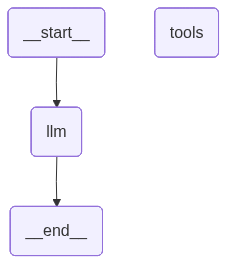

In [14]:
app

In [15]:
from langchain_core.messages import HumanMessage

result = app.invoke({
    "messages": [HumanMessage(content="What is the weather in Karachi?")]
})

print(result["messages"][-1].content)

**Karachi – 30 June 2026, 06:00 UTC**

- **Temperature:** 31 °C  
- **Precipitation:** Light drizzle (weather code 51)  
- **Wind:** 20 km/h from the west‑southwest (247°)  
- **Daytime:** Yes  

So it’s warm and breezy with a light drizzle in the morning.


In [16]:
result = app.invoke({
    "messages": [HumanMessage(content="Which is hotter right now, Karachi or Lahore?")]
})

print(result["messages"][-1].content)

Lahore is hotter right now.  
- **Karachi:** about 31 °C  
- **Lahore:** about 38 °C  

So Lahore has the higher temperature.
